<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Inferential_statistics_II_Hypothesis_association_correlation_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to Statistics IV**
---


Previously, we learned that statistics is the study of collecting, analyzing, and interpreting data. Today, humans generate and collect more data than ever before. Every time we send a text message, make an online purchase, or post a photo on social media, we generate new data. As the amount of data increases, so does the need to analyze and interpret it. This is a key reason why statistics and data-driven work are so important. Consequently, the field of data analysis is growing almost as rapidly as data itself.

Data professionals use statistics to analyze data in business, medicine, science, engineering, government, and more. Data professionals use the power of statistical methods to identify meaningful patterns and find relationships in data, analyze and quantify uncertainty, generate insights from data, make accurate predictions about the future, and solve complex problems.

Even if we haven't studied statistics, we probably use statistics every day. For example, we start our day by checking the weather online, where we learn that there is a 70 percent chance of rain or a 50 percent chance of snow. Perhaps we visit a sports website to learn about our favorite baseball player's batting average or basketball player's scoring average. In a news app, we might find an election poll that reports a three percent margin of error and notes that an online survey was used to collect the data. Or perhaps we're a parent, and when we take our child for a routine checkup, we learn that their height and weight fall within certain percentiles. When we ask for more information, the doctor shows us the median height and weight for all children the same age. These scenarios involve statistical concepts that we'll explore further.

In [ ]:
# importing libraries
# data manipulation
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistics
import statsmodels.api as sm
import scipy.stats as stats

# settings
import warnings
warnings.filterwarnings('ignore')

## **1. Hypothesis Testing for Proportions**

In the previous lesson, we learned about hypothesis testing on numerical data. The next question is how do we test hypotheses on categorical data?

This hypothesis test for proportions is used to test hypotheses on categorical data, such as "Yes" or "No" votes, "Buy" or "Don't Buy" decisions, "Subscribe" or "Not Subscribe," and other examples.

The following are the types of hypothesis tests for proportions.
- First, the Z-test for proportions in a single population.
- Second, the Z-test for proportions in two populations.
- Finally, the Chi-Squared Test for proportions in two independent categorical variables.

In [ ]:
# Loading dataset
bestsellerswithcategories_csv_url = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/bestsellers%20with%20categories.csv'
df = pd.read_csv(bestsellerswithcategories_csv_url)
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


### `a. One Sample Z-test`

This type of Z-test is used to test the hypothesis or assumption of whether the proportion of a group A is equal to the desired theoretical proportion assumption.

In this case, we want to test whether the proportion of fiction books is 50%.

We first state the null hypothesis and the alternative hypothesis.

- `H0`: $\text{Proportion}_\text{Fiction Books}$ = 0.5
- `H1`: $\text{Proportion}_\text{Fiction Books}$ != 0.5

Then we choose the significance level.
- Significance level ($\alpha$) = 0.05

Next, we calculate the p-value.

In [ ]:
# number of fiction books
n_fiction = len(df[df['Genre']=='Fiction'])
n_fiction

# number of books
n_all = len(df)
n_all

550

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

stat, pvalue = proportions_ztest(
count = n_fiction, # number of fiction books
nobs = n_all, # total number of books
value = 0.5 # proportion of the population / theoretical proportion to be tested
)

print(pvalue)

0.0026186572865008824


Finally, we draw the following conclusion:

In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho.
We do NOT have enough evidence to say that the proportion of fiction books is NOT equal to 0.5.
''')
else:
  print(f'''
pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
We have enough evidence to say that the proportion of fiction books is NOT equal to 0.5.
''')


pvalue = 0.00262. pvalue <= 0.05. Reject Ho.
We have enough evidence to say that the proportion of fiction books is NOT equal to 0.5.



### `b. Two Sample Z-test`

This hypothesis test is used to compare the proportions of two different groups.

In this case, we will use an A/B testing example.

An e-commerce company created a new UI design. Then, it was tested with 1,000 users given the old design (control group) and 1,000 users given the new design (treatment group). The test results are as follows:

In [ ]:
# create dummy data
np.random.seed(0)

visitor_data_before = np.random.binomial(1, 0.5, 1000)
visitor_data_after = np.random.binomial(1, 0.7, 1000)

visitor_data_before = np.where(visitor_data_before ==1, 'buying', 'no buying')
visitor_data_after = np.where(visitor_data_after ==1, 'buying', 'no buying')

df_old = pd.DataFrame({'layout':'old layout', 'conversion': visitor_data_before})
df_new = pd.DataFrame({'layout':'new layout', 'conversion': visitor_data_after})
df_all = pd.concat([df_old, df_new], axis=0, ignore_index=True)
df_all.sample(5)

,layout,conversion
1267,new layout,buying
237,old layout,no buying
1601,new layout,buying
640,old layout,buying
577,old layout,buying


We can create a summary table using `pivot_table` to see the total conversion on each layout.

In [ ]:
df_pivot  = df_all.pivot_table(
    index = 'layout',
    columns = 'conversion',
    values = 'conversion',
    aggfunc = len
)

df_pivot['total'] = df_pivot.sum(axis=1)
df_pivot.loc['total'] = df_pivot.sum(axis=0)
df_pivot

conversion,buying,no buying,total
layout,,,
new layout,664,336,1000
old layout,483,517,1000
total,1147,853,2000


Let's first state the null hypothesis and the alternative hypothesis.

- `H0`: $\text{transactions in the new layout design group are the same as in the old layout group}$
- `H1`: $\text{transactions in the new layout design group are greater than in the old layout group}$

Then we choose a significance level.
- Significance level ($\alpha$) = 0.05

Next, we calculate the p-value.

In [ ]:
n_buying_new = df_pivot.loc['new layout', 'buying']
print(n_buying_new)

664


In [ ]:
n_buying_old = df_pivot.loc['old layout', 'buying']
print(n_buying_old)

483


In [ ]:
n_all_new = df_pivot.loc['new layout', 'total']
print(n_all_new)

1000


In [ ]:
n_all_old = df_pivot.loc['old layout', 'total']
print(n_all_old)

1000


In [ ]:
stat, pvalue = proportions_ztest(
count = [n_buying_new, n_buying_old], # number of successful/buying events in each layout
nobs = [n_all_new, n_all_old], # number of data points in each layout
alternative = 'larger' # one tail larger
)

print(pvalue)

1.3789563948761732e-16


Then, we can draw conclusion:

In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to reject Ho.
  We do NOT have enough evidence to say that the proportion of buyers in the new layout group is GREATER than the proportion of buyers in the old layout group.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that the proportion of buyers in the new layout group is GREATER than the proportion of buyers in the old layout group.
''')


  pvalue = 0.00000. pvalue <= 0.05. Reject Ho.
  We have enough evidence to say that the proportion of buyers in the new layout group is GREATER than the proportion of buyers in the old layout group.



### `c. Chi-Square Test`

This hypothesis test is used to test the independence/relationship between two categorical variables.

Below is a crosstab of the two columns: Gender and Fruit.

In [ ]:
# Create a new dataframe
df_fruit = pd.DataFrame(
data= [[207,282,241], [234,242,232]],
columns= ['Banana', 'Mango', 'Pinaple'],
index= ['Male', 'Female']
)

df_fruit

,Banana,Mango,Pinaple
Male,207,282,241
Female,234,242,232


We will test whether gender is related to the choice of fruit to be purchased.

First, we state the null hypothesis and the alternative hypothesis.

- `H0`: $\text{Gender and Fruit are not related/independent (the proportions are the same)}$
- `H1`: $\text{Gender and Fruit are related/dependent (the proportions are significantly different)}$

To obtain the p-value, we must first obtain the **dof, expected_freq,** and **chi_square** values.

**Dof** or **degrees of freedom** is obtained using the formula

$$dof = \text{(number of rows-1)}\text{ x }\text{(number of columns-1)}$$

In [ ]:
n_rows = len(df_fruit)
n_columns = len(df_fruit.columns)

# calculate degrees of freedom
dof = (n_rows-1) * (n_columns-1)
dof

2

The **expected_freq** is calculated by multiplying the total in each row by the total in each column and dividing it by the overall total.

In [ ]:
df_fruit_total = df_fruit.copy()
df_fruit_total['Total'] = df_fruit_total.sum(axis=1)
df_fruit_total.loc['Total'] = df_fruit_total.sum(axis=0)
df_fruit_total

,Banana,Mango,Pinaple,Total
Male,207,282,241,730
Female,234,242,232,708
Total,441,524,473,1438


In [ ]:
# Method 1:
df_expected_freq = df_fruit_total.copy()

df_expected_freq.loc['Male', 'Banana'] = df_fruit_total.loc['Male', 'Total'] * df_fruit_total.loc['Total', 'Banana'] / df_fruit_total.loc['Total', 'Total']
df_expected_freq.loc['Male', 'Mango'] = df_fruit_total.loc['Male', 'Total'] * df_fruit_total.loc['Total', 'Mango'] / df_fruit_total.loc['Total', 'Total']
df_expected_freq.loc['Male', 'Pinaple'] = df_fruit_total.loc['Male', 'Total'] * df_fruit_total.loc['Total', 'Pinaple'] / df_fruit_total.loc['Total', 'Total']

df_expected_freq.loc['Female', 'Banana'] = df_fruit_total.loc['Female', 'Total'] * df_fruit_total.loc['Total', 'Banana'] / df_fruit_total.loc['Total', 'Total']
df_expected_freq.loc['Female', 'Mango'] = df_fruit_total.loc['Female', 'Total'] * df_fruit_total.loc['Total', 'Mango'] / df_fruit_total.loc['Total', 'Total']
df_expected_freq.loc['Female', 'Pinaple'] = df_fruit_total.loc['Female', 'Total'] * df_fruit_total.loc['Total', 'Pinaple'] / df_fruit_total.loc['Total', 'Total']

df_expected_freq

,Banana,Mango,Pinaple,Total
Male,223.873435,266.008345,240.11822,730
Female,217.126565,257.991655,232.88178,708
Total,441.000000,524.000000,473.00000,1438


In [ ]:
# Method 2

df_expected_freq = df_fruit_total.copy()

for index in df_fruit_total.index[:-1]:
  for column in df_fruit_total.columns[:-1]:
    df_expected_freq.loc[index, column] = df_fruit_total.loc[index, 'Total'] * df_fruit_total.loc['Total', column] / df_fruit_total.loc['Total', 'Total']

df_expected_freq

,Banana,Mango,Pinaple,Total
Male,223.873435,266.008345,240.11822,730
Female,217.126565,257.991655,232.88178,708
Total,441.000000,524.000000,473.00000,1438


Next, we can calculate the chi-square value using the formula:

$$ \chi^2 = \frac{\sum_{i=1}^n (O_i - E_i)^2}{E_i} $$

where:
- O = observed value
- E = expected value

In [ ]:
chi_square = 0

for index in df_fruit_total.index[:-1]:
  for column in df_fruit_total.columns[:-1]:
    chi_square += (df_fruit_total.loc[index, column] - df_expected_freq.loc[index, column])**2 / df_expected_freq.loc[index, column]

print(chi_square)

4.542228269825232


To calculate **pvalue**, we can use the table or formula provided by Python.

In [ ]:
pvalue = 1 - stats.chi2.cdf(chi_square, dof)
print(pvalue)

0.10319714047309392


If depicted in a graph, the results are as follows:

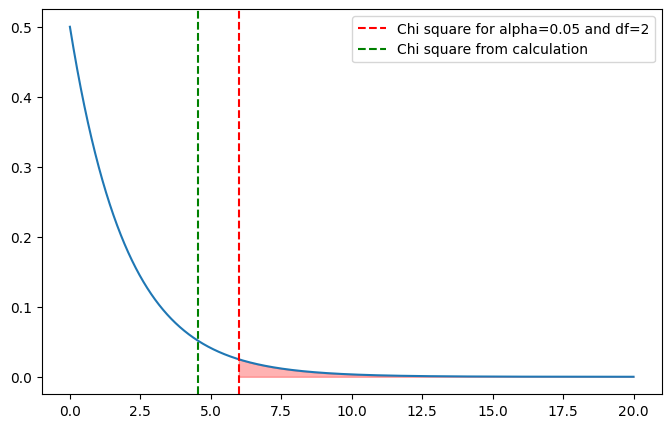

In [ ]:
#x-axis ranges from 0 to 20 with .001 steps
x = np.arange(0, 20, 0.001)

#plot Chi-square distribution with 2 degrees of freedom
fig, ax = plt.subplots(figsize=(8,5))

plt.plot(x, stats.chi2.pdf(x, df=dof))

line_x, line_y = ax.lines[0].get_data()

# calculate chi square for alpha 0.05 and degree of freedom 2
rejection = stats.chi2.ppf(1 - alpha, dof)

ax.axvline(
    x=rejection,
    color="red",
    linestyle='--',
    label='Chi square for alpha=0.05 and df=2'
)

ax.fill_between(
    line_x,
    line_y,
    where=(line_x >rejection),
    color='red',
    alpha=0.3
)

# plot chi square from calculation
ax.axvline(
    x=chi_square,
    color="green",
    linestyle='--',
    label='Chi square from calculation'
)

plt.legend()
plt.show()

From the graph, we can see that for a significance level of 0.05 and a degree of freedom of 2, the $\chi^2$ value is 5.991. We will reject `H0` if the $\chi^2$ value from the calculation is above 5.991. However, we can see that the $\chi^2$ value from the calculation, namely 4.54, is to the left of the rejection area. Therefore, we fail to reject `H0`.

All the calculations and interpretations above can be done quickly in the following way:

In [ ]:
df_fruit

,Banana,Mango,Pinaple
Male,207,282,241
Female,234,242,232


In [ ]:
from scipy.stats import chi2_contingency

stat, pvalue, dof, expected_freq = chi2_contingency(df_fruit)
print(pvalue)

0.1031971404730939


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to reject Ho.
We do NOT have enough evidence to say that there is a relationship (dependence) between Gender and Fruit.
''')
else:
  print(f'''
pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
We have enough evidence to say that there is a relationship (dependence) between Gender and Fruit.
''')


pvalue = 0.10320. pvalue > 0.05. Fail to reject Ho.
We do NOT have enough evidence to say that there is a relationship (dependence) between Gender and Fruit.



## **2. Correlation**

Correlation is a type of relationship that does not imply cause and effect. Correlation does not distinguish between the response variable and the explanatory variable. For example, a study has shown that vacation intensity is correlated with a person's income. This does not mean that more vacations will increase a person's income.

Correlation only measures the strength of a relationship and the direction of that relationship.

Correlation has a direction:
- A **positive** correlation means the direction of the relationship is linear, such as the relationship between rice field area and total rice production.
- A **negative** correlation means the direction of the relationship is inverse, such as the relationship between the total rat population in rice fields and total rice production.

Correlation values range between -1 and 1. The following are guidelines for assessing correlation test results:

| Value of Correlation Coefficient | Relationship Interpretation |
| --- | --- |
| 0.000 - 0.199 | Very Weak |
| 0.200 - 0.399 | Weak |
| 0.400 - 0.599 | Moderate |
| 0.600 - 0.799 | Strong |
| 0.800 - 1.000 | Very Strong |

In general, the direction and strength of a relationship can be visualized as follows:

![](https://cdn1.byjus.com/wp-content/uploads/2021/03/Correlation.png)

There are two types of correlation that we will study, namely:
- Pearson
- Spearman

### `a. Pearson`

If we have two vectors of equal length, $x$ and $y$, where each element of $x$ is paired with a corresponding element of $y$, the covariance provides a measure of how related the variables are to each other:

​$$ \text{cov}(x, y) = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) }{n} $$

Where:

- $\text{cov}(x, y)$ is the covariance between vectors $x$ and $y$.
- $n$ is the number of elements in the vectors.
- $x_i$ and $y_i$ are the $i$ elements of vectors $x$ and $y$, respectively.
- $\bar{x}$ and $\bar{y}$ are the averages of the vectors $x$ and $y$, respectively.

One weakness of covariance is that it obscures the relative scale of two variables as a measure of their relationship. Correlation builds on covariance and overcomes this weakness by rescaling, thus measuring (linear) relationship exclusively. Correlation is much more general because of this difference.

The correlation coefficient (developed by Karl Pearson in the 20th century, although known since the 19th century) is often denoted by $r$ or $\rho$ and is defined by:

​$$ \rho_{x,y} = \frac{\text{cov}(x,y)}{\sigma_x \sigma_y} $$

Where:

- $\rho_{x,y}$ is the correlation coefficient between variables $x$ and $y$.

- $\text{cov}(x,y)$ is the covariance between variables $x$ and $y$.
- $\sigma_x$ and $\sigma_y$ are the standard deviations of variables $x$ and $y$, respectively.

Pearson correlation is a measure of correlation used to measure the strength and direction of a linear relationship between two variables. Pearson correlation is usually applied to data assumed to be normally distributed and to have a linear relationship (a straight line).

We will attempt to calculate the Pearson correlation of sepal length (`sepal_length`) and petal length (`petal_length`) in the iris dataset in seaborn.

In [ ]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


First of all, let's try to display the scatterplot of `sepal_length` and `petal_length` to see the picture of the relationship between the two.

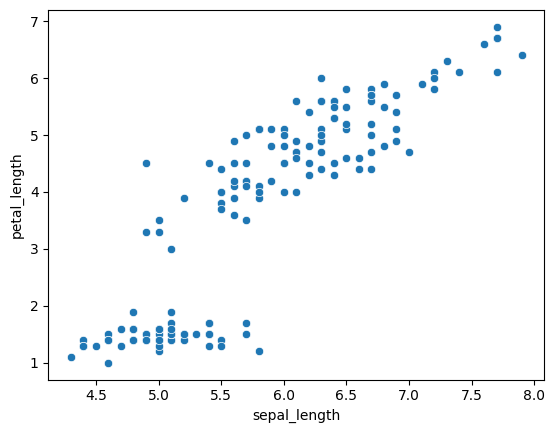

In [ ]:
x = iris['sepal_length']
y = iris['petal_length']

sns.scatterplot(data=iris, x = x, y = y)
plt.show()

Next, we will first calculate the covariance between `sepal_length` and `petal_length`

In [ ]:
# Calculate the average
xbar = x.mean()
ybar = y.mean()

# Number of data points
n = len(iris)
n

# Calculate the product
products = []

for i in range(n):
  products.append((x[i] - xbar)*(y[i] - ybar))

covariance = np.sum(products) / n
print(covariance)

1.26582


Next we calculate $\rho$ with the Pearson formula above:

In [ ]:
r = covariance / (np.std(x) * np.std(y))
print(r)

0.8717537758865831


We've reached this point in Probability. Now, regarding how to determine the p-value, we first calculate the t-statistic.

$$ t = r \sqrt{\frac{n-2}{1-r^2}} $$

In [ ]:
t = r * np.sqrt((n-2)/(1-r**2))
print(t)

21.646019345759765


Next we can calculate the p value

In [ ]:
pvalue = 2 * stats.t.cdf(-abs(t), n-2)
print(pvalue)

1.0386674194498124e-47


All the above steps can be calculated with 1 line of code using the `pearsonr()` method:

In [ ]:
from scipy.stats import pearsonr

stat, pvalue = pearsonr(x, y)
print(pvalue)

1.0386674194498771e-47


Interpretation of the correlation (r=0.872)

- (+) The relationship is positive, the higher the `sepal_length`, the higher the `petal_length`.
- The value is 0.871, a very strong relationship.

We can also calculate the correlation of each numerical column in the iris dataset in the following way:

In [ ]:
iris.select_dtypes(include=np.number).corr(method='pearson')

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


### `b. Spearman`

Spearman correlation is a measure of correlation used to measure the strength and direction of a non-linear relationship between two variables.

Spearman correlation can be used to measure correlation in data:

- **Non-Parametric**: no assumptions about data distribution
- The relationship is non-linear (does not form a straight line) and **monotonic**
- Can be used for ordinal categorical columns

We will also attempt to calculate the Spearman correlation of sepal length (`sepal_length`) and corolla length (`petal_length`) using the `spearmanr()` method.

In [ ]:
from scipy.stats import spearmanr

r, pvalue = spearmanr(x, y)
print(r)

0.881898126434986


Or we can also use `.corr(method='spearman')`

In [ ]:
iris.select_dtypes(include=np.number).corr(method='spearman')

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.166778,0.881898,0.834289
sepal_width,-0.166778,1.000000,-0.309635,-0.289032
petal_length,0.881898,-0.309635,1.000000,0.937667
petal_width,0.834289,-0.289032,0.937667,1.000000


Or we can also calculate manually using the following formula:

​$$ \rho = 1 - \frac{6\sum_{i=1}^n \text{diff}^2}{n(n^2-1)} $$

In [ ]:
spearman_table = iris[['sepal_length', 'petal_length']].copy()
spearman_table['sepal_length_rank'] = spearman_table['sepal_length'].rank()
spearman_table['petal_length_rank'] = spearman_table['petal_length'].rank()
spearman_table['diff'] = spearman_table['sepal_length_rank'] - spearman_table['petal_length_rank']
spearman_table['diff^2'] = spearman_table['diff'] ** 2
spearman_table

,sepal_length,petal_length,sepal_length_rank,petal_length_rank,diff,diff^2
0,5.1,1.4,37.0,18.0,19.0,361.00
1,4.9,1.4,19.5,18.0,1.5,2.25
2,4.7,1.3,10.5,8.0,2.5,6.25
3,4.6,1.5,7.5,31.0,-23.5,552.25
4,5.0,1.4,27.5,18.0,9.5,90.25
...,...,...,...,...,...,...
145,6.7,5.2,126.5,117.5,9.0,81.00
146,6.3,5.0,104.0,106.5,-2.5,6.25
147,6.5,5.2,118.0,117.5,0.5,0.25
148,6.2,5.4,97.5,121.5,-24.0,576.00


In [ ]:
top_section = 6 * spearman_table['diff^2'].sum()
print(top_section)

397791.0


In [ ]:
bottom_section = n * (n**2 - 1)
print(bottom_section)

3374850


In [ ]:
r_spearman = 1 - (top_section/bottom_section)
print(r_spearman)

0.8821307613671718


### `Simpson's Paradox`

This is a phenomenon in statistics where the trend of some data sets is the opposite of the combined trend of the entire data set.

For example, consider a study examining the relationship between education level and crime. Consider the following table.

In [ ]:
df_crime  = pd.DataFrame({
    'education' : [70, 75, 80, 85, 55, 58, 60, 65],
    'crime' : [140, 120, 110, 105, 50, 40, 30, 25],
    'location' : ['urban', 'urban', 'urban', 'urban', 'rural', 'rural', 'rural', 'rural']
})

df_crime

,education,crime,location
0,70,140,urban
1,75,120,urban
2,80,110,urban
3,85,105,urban
4,55,50,rural
5,58,40,rural
6,60,30,rural
7,65,25,rural


If we only analyze education levels and crime rates, we could make the wrong assumption that the higher the education level, the higher the number of crimes.

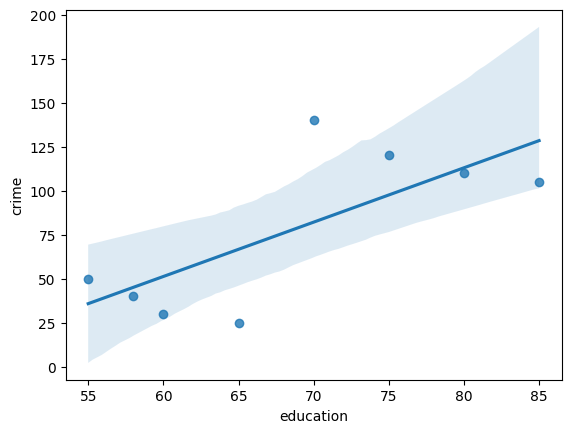

In [ ]:
sns.regplot(data=df_crime, x='education', y='crime')
plt.show()

Compare this to an analysis that separates rural and urban dwellers. The results would be different.

In [ ]:
df_crime[df_crime['location']=='urban']

,education,crime,location
0,70,140,urban
1,75,120,urban
2,80,110,urban
3,85,105,urban


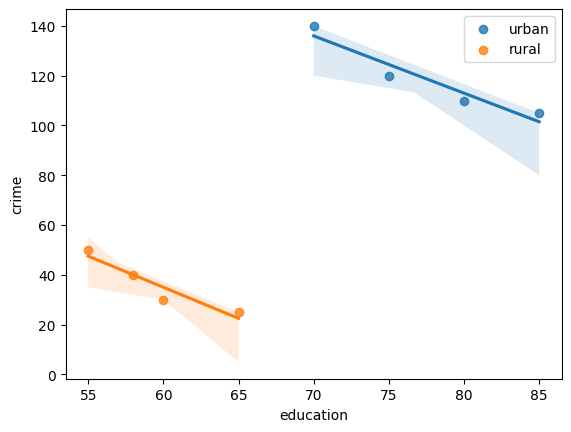

In [ ]:
sns.regplot(data=df_crime[df_crime['location']=='urban'], x='education', y='crime', label='urban')
sns.regplot(data=df_crime[df_crime['location']=='rural'], x='education', y='crime', label='rural')
plt.legend()
plt.show()

If separated as in the graph above, both in cities and villages, the higher the level of education, the lower the crime rate.

### `Correlation vs. Causation`

Correlation does not imply causality per se. For example, sepal length and petal length are highly correlated, but this does not mean that sepal length causes petal length or vice versa.

There is a lot to learn about causality, and I recommend Judea Pearl's [*Causality*](http://bayes.cs.ucla.edu/BOOK-2K/), the classic technical text on the topic, if you want to explore it in depth. [*The Book of Why*](http://bayes.cs.ucla.edu/WHY/) is an excellent alternative for the general reader from the same author.

Briefly, there are three criteria required to infer a causal relationship:

1. **Covariation**: Two variables vary together (this criterion is met by both sepal and petal length).
2. **Temporal precedence**: The affected variable must vary after the causative variable varies.
3. **Elimination of extraneous variables**: We must be sure that no third variables are causing the variation. This can be difficult for data obtained solely through observation, but is easier when we can control for the causal variables, for example, with a randomized control trial (ideally double-blind).

## **3. Summary**

In general, all the tests we conducted can be summarized in the following table:

| | Parametric | Non-parametric |
| --- | --- | --- |
| Assumed distribution | Normal | Any |
| Assumed variance | Homogeneous | Any |
| Data set relationships | Independent | Any |
| Usual central measure | Mean | Median |
| Benefits | can draw more conclusions | Simplicity; Less affected by outliers |
| Tests | | |
| Correlation test | Pearson | Spearman |
| Independent measures, 2 groups | Independent-measures t-test | Mann-Whitney test |
| Independent measures, >2 groups | One-way, independent-measures ANOVA | Kruskall-Wallis test |
| Repeated measures, 2 conditions | Matched-pair t-test | Wilcoxon test |
| Repeated measures, >2 conditions | One-way, repeated-measures ANOVA | Friedman's test |

As for the visualization, it can be seen as follows:

![hipotesis.png](https://github.com/harishmuh/Python-for-Data-Science-Analysis/blob/main/Assets/Statistics_Hypothesis%20test.png?raw=true)



